In [1]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 42.9 MB/s eta 0:00:00


In [3]:
from datetime import timedelta as td, datetime, date
import pandas as pd
import requests
from io import StringIO
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import calendar
import koreanize_matplotlib
#from dateutil.relativedelta import relativedelta as rtd

def get_code_name():
	code_all = pd.read_html('http://kind.krx.co.kr/corpgeneral/corpList.do?method=download', header=0, encoding='euc-kr')
	columns = code_all[0].columns
	df = code_all[0][[columns[0], columns[2]]]
	df.columns=['names', 'code']
	df['change_price'] = np.nan
	return df

def start_end():
	end = datetime.now()-td(days=1)
	start = datetime.now()-td(days=100)
	return start, end

In [12]:
def get_change_price(df):
	start, end = start_end()
	for i, j in enumerate(df.code):
		target_code = j
		stock = web.DataReader(target_code, 'naver', start=start, end=end)
		change_price = int(stock.iloc[-1, 3]) - int(stock.iloc[0, 3])
		df.iloc[i, 2] = change_price
	return df

def data_from_csv():
	file_name = 'stock_name_code_ChangePrice.csv'
	df = pd.read_csv(file_name)
	df = df.iloc[:, 1:]
	df.columns=['names', 'code', 'change_price']
	return df

In [13]:
def get_eps(df):
	df_10 = df.sort_values(by='change_price', ascending=False)[:10]
	df_dict = {}
	for i, j in df_10.iterrows():
		url = f"https://finance.naver.com/item/main.nhn?code={j.code}"
		financial_stmt = pd.read_html(StringIO(requests.get(url).text))
		if type(financial_stmt[3].columns) != type(financial_stmt[0].columns):
			df = financial_stmt[3].iloc[9, :]
		else:
			df = financial_stmt[4].iloc[9, :]
		if len(df)<4:
			continue
		df.name = j.names
		df_dict[j.code] = df
	return (df_dict, df_10)

In [14]:
def date_transform(df):
    for i in df.index:
        str_date = df.loc[i].level_1
        year = int(str_date[:4])
        month = int(str_date[5:7])
        fd, last_day = calendar.monthrange(year, month)
        dates = date(year, month, last_day)
        df.loc[i,'level_1']=dates
    return df

def select_figure(df):
    name = df.columns[-1]
    df_value = pd.to_numeric(df[name])
    if len(df_value) == len(df_value[df_value>0]):
        return True
    return False

In [15]:
def get_date_timestamp(dfs):
    df_dict = dfs.copy()
    for i in df_dict:
        df = df_dict[i]
        df = df.dropna()
        df = df.reset_index()
        name = df.columns[3]
        df = df[df.level_0 == '최근 분기 실적'][['level_1', name]]
        df = date_transform(df)
        start=date(df.iloc[0, 0].year, df.iloc[0,0].month,1)
        end=df.iloc[-1, 0]
        select_figure_TF = select_figure(df)
        df_dict[i] = [start, end, select_figure_TF, df]
    return df_dict

def get_stock_data(df_trans):
    for i in df_trans:
        start = df_trans[i][0]
        #end = df_trans[i][1]
        end = date.today()
        df = web.DataReader(i, 'naver', start=start, end=end)
        df = df['Close']
        df = pd.to_numeric(df)
        df_trans[i].append(df)
    return df_trans

In [16]:
def adj_datetime_data(df):
    df_dict={}
    for i in df:
        df2 = df[i][3]
        df2[df2.columns[0]] = pd.to_datetime(df2[df2.columns[0]])
        df2[df2.columns[1]] = pd.to_numeric(df2[df2.columns[1]])
        df2.set_index('level_1', inplace=True)
        df_dict[i] = [df[i][2], df[i][4], df2]
    return df_dict

In [36]:
def plot_data(i, stock, eps):
    company = eps.columns[-1]
    fig, ax = plt.subplots(figsize=(8,6))
    eps_ax = ax.twinx()
    ax.plot(stock.index, stock.values, label='주가')
    eps_ax.plot(eps.index, eps[company], 'o-r', label='주당순이익')
    plt.title(company)
    ax.legend(loc='upper left')
    eps_ax.legend(loc='lower right')
    file_name = './' + str(i) + '.png'
    plt.savefig(file_name)

def plots(df):
    for i in df:
        stock = df[i][1]
        eps_data = df[i][2]
        plot_data(i, stock, eps_data)

In [19]:
df = data_from_csv()

In [20]:
df.head()

,names,code,change_price
0,보원케미칼,0010F0,-610.0
1,교보20호스팩,0132G0,-10.0
2,인벤테라,0007J0,-10000.0
3,신한제17호스팩,0130D0,-25.0
4,리센스메디컬,394420,3650.0


In [21]:
df_dict_eps, df_10 = get_eps(df)

In [23]:
df_dict_eps # key , 데이터 프레임 가져오기

{'298040': 주요재무정보    주요재무정보      주요재무정보     EPS(원)
 최근 연간 실적  2023.12     IFRS연결    12438.0
           2024.12     IFRS연결    23876.0
           2025.12     IFRS연결    55755.0
           2026.12(E)  IFRS연결    84943.0
 최근 분기 실적  2024.12     IFRS연결     9766.0
           2025.03     IFRS연결      10956
           2025.06     IFRS연결       9922
           2025.09     IFRS연결      16109
           2025.12     IFRS연결    18769.0
           2026.03(E)  IFRS연결    14108.0
 Name: 효성중공업, dtype: object,
 '012450': 주요재무정보    주요재무정보      주요재무정보     EPS(원)
 최근 연간 실적  2023.12     IFRS연결    15886.0
           2024.12     IFRS연결    46183.0
           2025.12     IFRS연결    28573.0
           2026.12(E)  IFRS연결    44871.0
 최근 분기 실적  2024.12     IFRS연결    39855.0
           2025.03     IFRS연결       1868
           2025.06     IFRS연결       4193
           2025.09     IFRS연결       9501
           2025.12     IFRS연결    12266.0
           2026.03(E)  IFRS연결     8194.0
 Name: 한화에어로스페이스, dtype: object,
 '000150': 주요재무정

In [24]:
df_trains = get_date_timestamp(df_dict_eps)

In [25]:
df_trains

{'298040': [datetime.date(2024, 12, 1),
  datetime.date(2026, 3, 31),
  True,
         level_1    효성중공업
  5   2024-12-31   9766.0
  6   2025-03-31    10956
  7   2025-06-30     9922
  8   2025-09-30    16109
  9   2025-12-31  18769.0
  10  2026-03-31  14108.0],
 '012450': [datetime.date(2024, 12, 1),
  datetime.date(2026, 3, 31),
  True,
         level_1 한화에어로스페이스
  5   2024-12-31   39855.0
  6   2025-03-31      1868
  7   2025-06-30      4193
  8   2025-09-30      9501
  9   2025-12-31   12266.0
  10  2026-03-31    8194.0],
 '000150': [datetime.date(2024, 12, 1),
  datetime.date(2026, 3, 31),
  False,
         level_1      두산
  5   2024-12-31 -7633.0
  6   2025-03-31    1104
  7   2025-06-30    3670
  8   2025-09-30    5656
  9   2025-12-31 -6944.0
  10  2026-03-31  3751.0],
 '079550': [datetime.date(2024, 12, 1),
  datetime.date(2026, 3, 31),
  True,
         level_1  LIG넥스원
  5   2024-12-31  3191.0
  6   2025-03-31    3828
  7   2025-06-30    4781
  8   2025-09-30    2696
  9   2025

In [27]:
df_ = get_stock_data(df_trains)

In [30]:
len(df_['298040'])

6

In [31]:
df_['298040'][3]

,level_1,효성중공업
5,2024-12-31,9766.0
6,2025-03-31,10956
7,2025-06-30,9922
8,2025-09-30,16109
9,2025-12-31,18769.0
10,2026-03-31,14108.0


In [32]:
df_['298040'][4]

,Close
Date,
2024-12-02,386000
2024-12-03,424500
2024-12-04,429000
2024-12-05,439500
2024-12-06,426000
...,...
2026-04-07,2610000
2026-04-08,2930000
2026-04-09,2882000


In [33]:
TF_stock_eps_dict = adj_datetime_data(df_)

In [34]:
TF_stock_eps_dict

{'298040': [True,
  Date
  2024-12-02     386000
  2024-12-03     424500
  2024-12-04     429000
  2024-12-05     439500
  2024-12-06     426000
                 ...   
  2026-04-07    2610000
  2026-04-08    2930000
  2026-04-09    2882000
  2026-04-10    2940000
  2026-04-13    3058000
  Name: Close, Length: 330, dtype: int64,
                효성중공업
  level_1            
  2024-12-31   9766.0
  2025-03-31  10956.0
  2025-06-30   9922.0
  2025-09-30  16109.0
  2025-12-31  18769.0
  2026-03-31  14108.0],
 '012450': [True,
  Date
  2024-12-02     316090
  2024-12-03     333322
  2024-12-04     329876
  2024-12-05     303289
  2024-12-06     293442
                 ...   
  2026-04-07    1537000
  2026-04-08    1484000
  2026-04-09    1451000
  2026-04-10    1507000
  2026-04-13    1530000
  Name: Close, Length: 330, dtype: int64,
              한화에어로스페이스
  level_1              
  2024-12-31    39855.0
  2025-03-31     1868.0
  2025-06-30     4193.0
  2025-09-30     9501.0
  2025-12-31    

In [38]:
df_10

,names,code,change_price
888,효성중공업,298040,1095000.0
64,본시스템즈,496320,707700.0
2577,한화에어로스페이스,012450,561000.0
2732,두산,000150,518000.0
1147,LIG넥스원,079550,482000.0
2686,태광산업,003240,423000.0
2265,SK하이닉스,000660,350000.0
2378,엘에스일렉트릭,010120,295500.0
2607,삼성전기,009150,295000.0
2442,고려아연,010130,294000.0


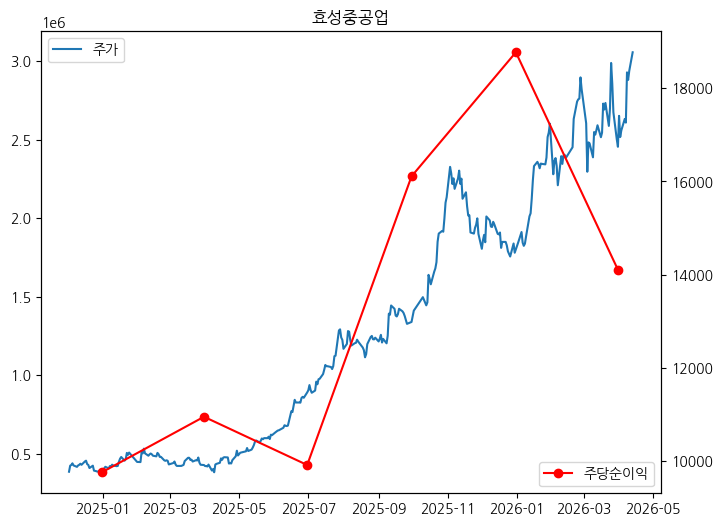

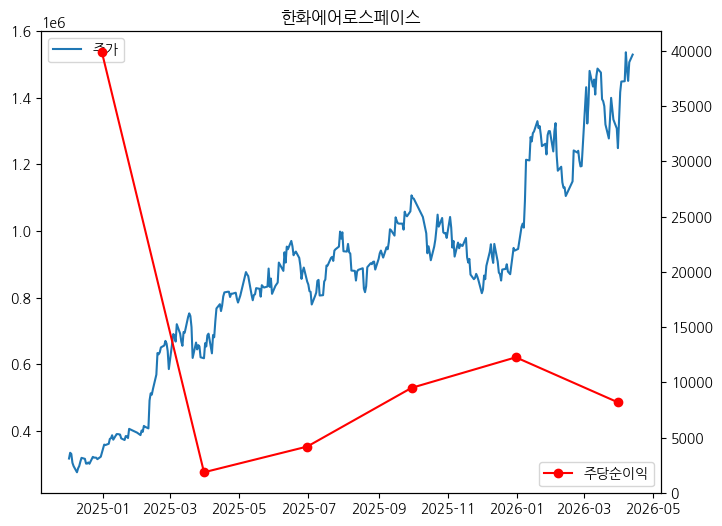

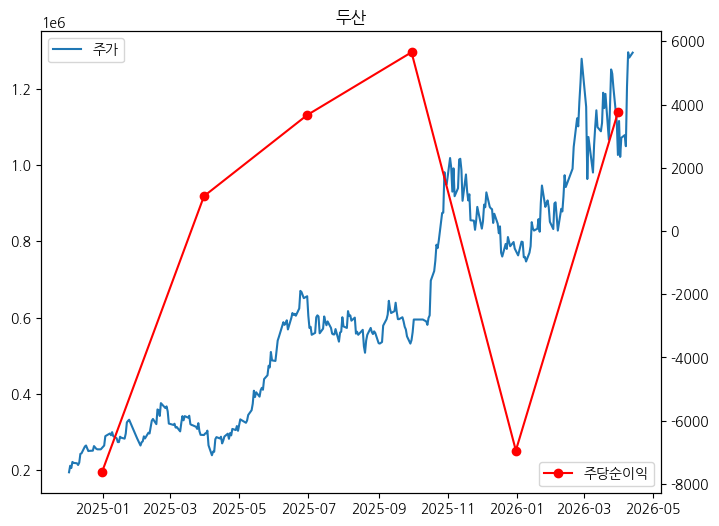

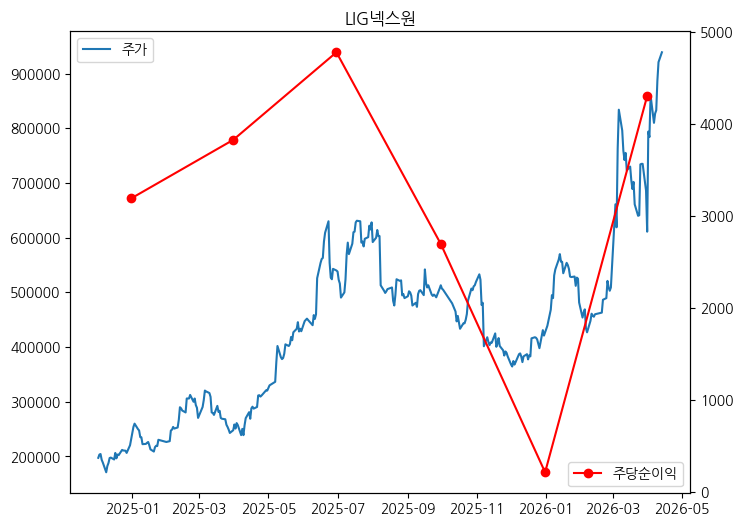

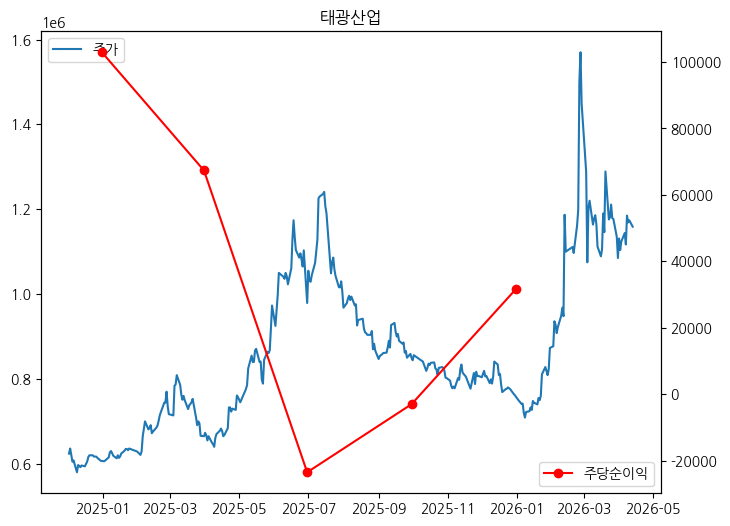

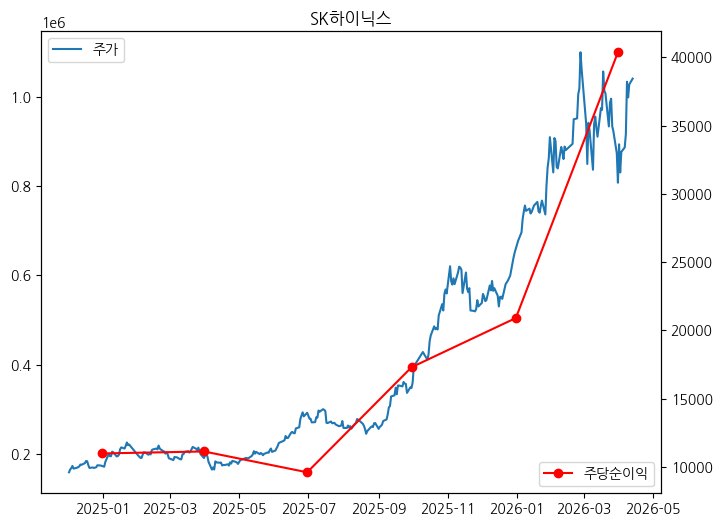

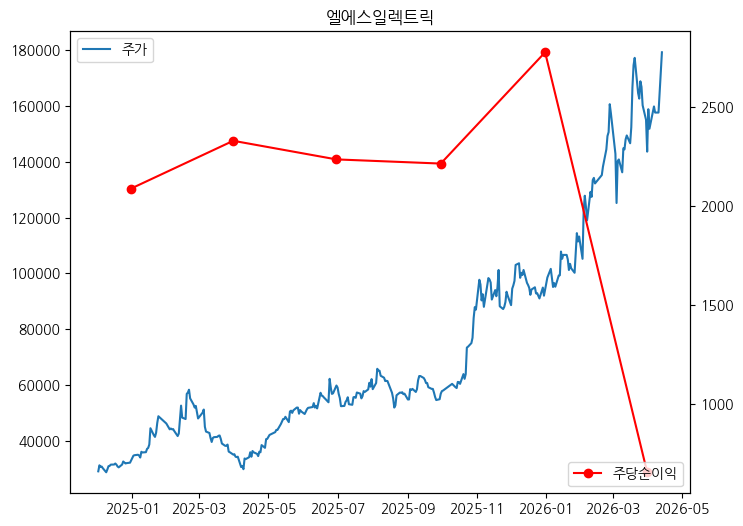

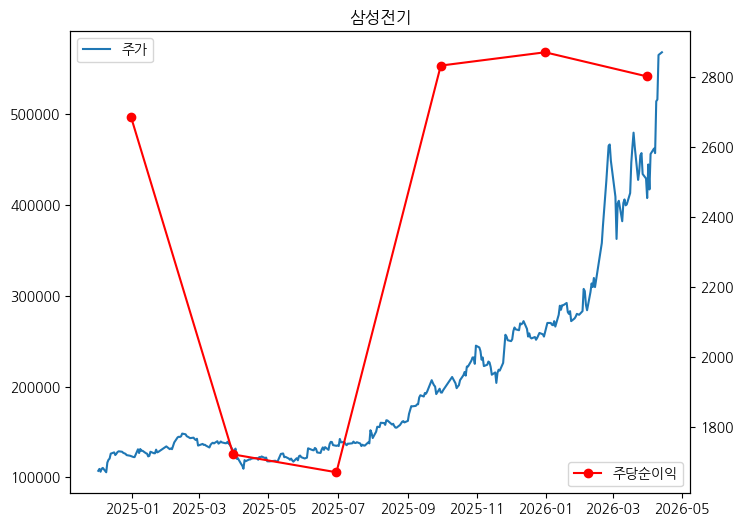

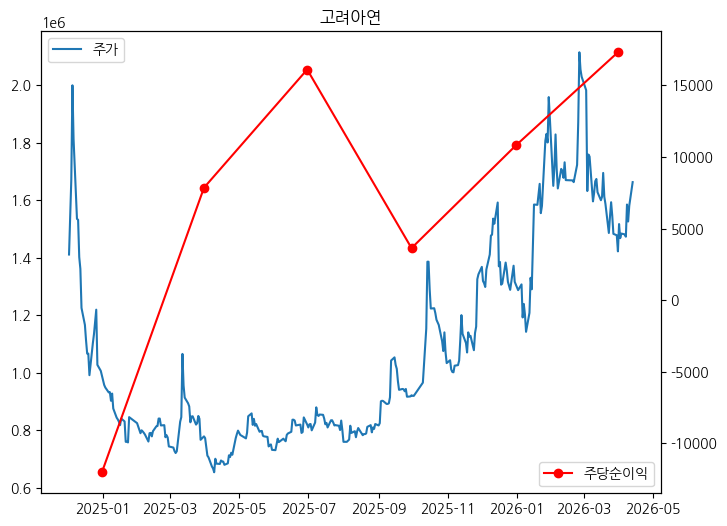

In [37]:
plots(TF_stock_eps_dict)